====================== Image Augmentation ======================

### Why Image Augmentation?

Large datasets are key to deep learning success, but collecting more data is expensive. **Image augmentation** generates modified training images on-the-fly, effectively expanding the dataset and improving generalization.

- Augmented images are **random transformations** of the originals — the model never sees the exact same image twice.
- Augmentation acts as a **regularizer**, reducing overfitting.
- At **test time**, no augmentation is applied (or predictions are averaged over multiple augmented copies).
- Use augmented images **only during training**.
- With augmentation, the model learns features **invariant** to the transformations (e.g., object position, lighting).

### Common Augmentation Techniques

| Technique | Description | PyTorch Transform |
|---|---|---|
| **Horizontal Flip** | Mirror image left-right (50% probability) | `RandomHorizontalFlip()` |
| **Vertical Flip** | Mirror image top-bottom | `RandomVerticalFlip()` |
| **Random Crop** | Crop a random region, resize back | `RandomResizedCrop(size, scale=(0.1, 1), ratio=(0.5, 2))` |
| **Color Jitter** | Randomly change brightness, contrast, saturation, hue | `ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)` |
| **Combine All** | Chain multiple transforms | `Compose([...])` |

### Key Takeaways

- Image augmentation is a **cheap** way to enlarge training data and reduce overfitting.
- The choice of augmentations should reflect **realistic variations** the model might encounter.
- Horizontal flipping and random cropping are almost universally beneficial; color jitter helps when lighting varies.
- Augmentation is a form of **implicit regularization** complementary to dropout and weight decay.

In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

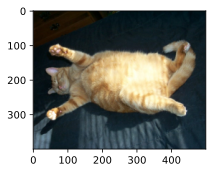

In [2]:
d2l.set_figsize()
img = d2l.Image.open('../img/cat1.jpg')
d2l.plt.imshow(img);

In [ ]:
# Most image augmentation methods have a certain degree of randomness. To make it easier for us 
# to observe the effect of image augmentation, next we define an auxiliary function apply. 
# This function runs the image augmentation method multiple times on the input image img 
# and shows all the results.


def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

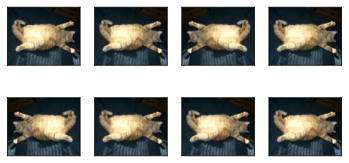

In [4]:
apply(img, torchvision.transforms.RandomHorizontalFlip())

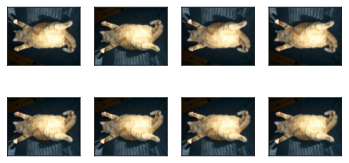

In [5]:
apply(img, torchvision.transforms.RandomVerticalFlip())

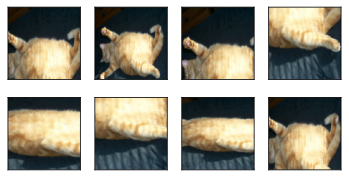

In [ ]:
# In the code below, we randomly crop an area with an area of 10% - 100% of the original area 
# each time, and the ratio of width to height of this area is randomly selected from 0.5 - 2.
# Then, the width and height of the region are both scaled to 200 pixels. Unless otherwise 
# specified, the random number between a and b in this section refers to a continuous value
# obtained by random and uniform sampling from the interval [a, b].


shape_aug = torchvision.transforms.RandomResizedCrop(
    (200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

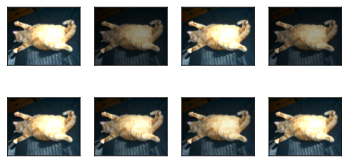

In [ ]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0, saturation=0, hue=0))

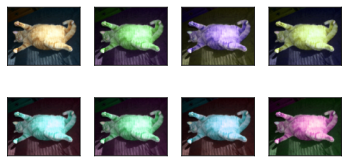

In [8]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0, contrast=0, saturation=0, hue=0.5))

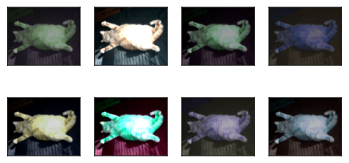

In [9]:
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

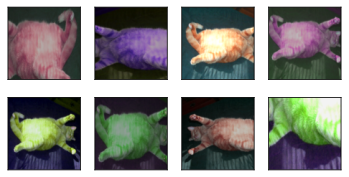

In [10]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug])
apply(img, augs)

Files already downloaded and verified


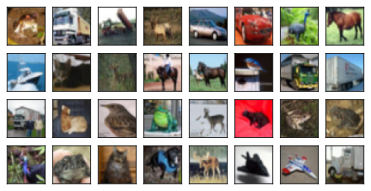

In [ ]:
all_images = torchvision.datasets.CIFAR10(train=True, root="../data", download=True)
d2l.show_images([all_images[i][0] for i in range(32)], 4, 8, scale=0.8);

In [12]:
train_augs = torchvision.transforms.Compose([
     torchvision.transforms.RandomHorizontalFlip(),
     torchvision.transforms.ToTensor()])

test_augs = torchvision.transforms.Compose([
     torchvision.transforms.ToTensor()])

In [13]:
def load_cifar10(is_train, augs, batch_size):
    dataset = torchvision.datasets.CIFAR10(root="../data", train=is_train,
                                           transform=augs, download=True)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                    shuffle=is_train, num_workers=d2l.get_dataloader_workers())
    return dataloader

In [ ]:
#@save
def train_batch_ch13(net, X, y, loss, trainer, devices):
    """Train for a minibatch with multiple GPUs (defined in Chapter 13)."""
    # Step 1: move the incoming minibatch to devices[0] first.
    # Step 2: if `net` is nn.DataParallel, calling net(X) will automatically
    # scatter/split this minibatch from devices[0] to the other GPUs listed in
    # `device_ids` for parallel forward/backward.
    # This can look like "copying twice" and adds overhead, so it is less
    # efficient than DDP (DistributedDataParallel) for large-scale training.
    if isinstance(X, list):
        # Required for BERT fine-tuning (to be covered later).
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])

    # Multi-GPU happens only when `net` is wrapped by DataParallel.
    # Otherwise this runs as normal single-device training.
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = d2l.accuracy(pred, y)
    return train_loss_sum, train_acc_sum

#@save
def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               devices=d2l.try_all_gpus()):
    """Train a model with multiple GPUs (defined in Chapter 13)."""
    if not devices:
        devices = [torch.device('cpu')]
    timer, num_batches = d2l.Timer(), len(train_iter)
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                            legend=['train loss', 'train acc', 'test acc'])

    if devices[0].type == 'cuda':
        # DataParallel behavior summary:
        # 1) `devices[0]` holds the master copy of parameters.
        # 2) train_batch_ch13 first places each minibatch on `devices[0]`.
        # 3) `net(X)` then scatters that minibatch across all GPUs in
        #    `device_ids` and runs replicas in parallel.
        # 4) Gradients are reduced back to `devices[0]` before optimizer step.
        # So it is multi-GPU if `len(devices) > 1`; only single-GPU when just
        # one CUDA device is available/listed.
        # In this notebook, we use this because training runs in one process.
        # `devices[0]` is the primary device for that process.
        #
        # DDP is generally preferred for performance/scaling:
        # - One process per GPU (each process keeps data on its local GPU).
        # - No central scatter/gather bottleneck on `devices[0]`.
        # - Faster and more stable scaling on multi-GPU/multi-node training.
        # - Requires process-group setup and distributed samplers.
        net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    else:
        # CPU path (no DataParallel here).
        net = net.to(devices[0])

    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        metric = d2l.Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(
                net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3],
                              None))
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on '
          f'{str(devices)}')

In [15]:
devices = d2l.try_all_gpus()
if not devices:
    devices = [torch.device('cpu')]
batch_size, net = 256, d2l.resnet18(10, 3)
net.apply(d2l.init_cnn)

def train_with_data_aug(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction="none")
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    net(next(iter(train_iter))[0])
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, devices)

/workspaces/pytorch-d2l/.venv310/lib/python3.10/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


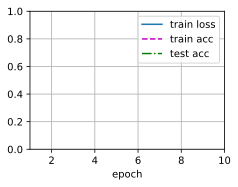

In [ ]:
train_with_data_aug(train_augs, test_augs, net)

============================ Fine-Tuning ============================

### The Problem: Limited Data for New Tasks

Training a deep CNN from scratch requires millions of labeled images. Most real-world tasks have far fewer. **Transfer learning** via **fine-tuning** solves this by reusing a model pretrained on a large dataset (e.g., ImageNet).

### How Fine-Tuning Works

!["Fine tunning"](./Images/14/FineTunning.png)

#### Step-by-Step

1. **Pretrain** a model on a large source dataset (or download pretrained weights).
2. **Create target model**: Copy all layers except the output layer; initialize a new output layer for the target task.
3. **Train on target dataset**:
   - The new output layer is trained **from scratch** (larger learning rate).
   - All other layers are **fine-tuned** (smaller learning rate).

### Why It Works

| Layer Level | What It Learns | Transferability |
|---|---|---|
| **Early layers** | Edges, textures, colors | Highly transferable across tasks |
| **Middle layers** | Object parts, patterns | Moderately transferable |
| **Late layers** | Task-specific features | Less transferable — need retraining |

- Features learned from large datasets are **generic** enough to be useful for many tasks.
- Fine-tuning is much faster than training from scratch and works well even with small target datasets.

### Key Takeaways

- **Fine-tuning** transfers knowledge from source to target, requiring much less data and compute.
- Use a **smaller learning rate** for pretrained layers to preserve learned features; a **larger rate** for the new output layer.
- The more similar the source and target domains, the better the transfer.
- Fine-tuning is the **default strategy** in modern computer vision for tasks with limited data.

In [ ]:
%matplotlib inline
import os
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

In [ ]:
#@save
d2l.DATA_HUB['hotdog'] = (d2l.DATA_URL + 'hotdog.zip',
                         'fba480ffa8aa7e0febbb511d181409f899b9baa5')

data_dir = d2l.download_extract('hotdog')

In [ ]:
train_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'))
test_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'))

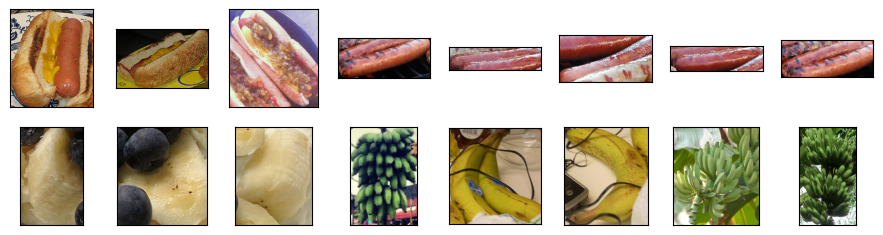

In [ ]:
# The first 8 positive examples and the last 8 negative images are shown below. 
# As you can see, the images vary in size and aspect ratio.

hotdogs = [train_imgs[i][0] for i in range(8)]
not_hotdogs = [train_imgs[-i - 1][0] for i in range(8)]
d2l.show_images(hotdogs + not_hotdogs, 2, 8, scale=1.4);

In [ ]:
# During training, we first crop a random area of random size and random aspect ratio from the image, 
# and then scale this area to a 224*224 input image. During testing, we scale both the height and width of
# an image to 256 pixels, and then crop a central 224*224 area as input. 
# In addition, for the three RGB (red, green, and blue) color channels we standardize their values channel
# by channel. 
# Concretely, the mean value of a channel is subtracted from each value of that channel and then the result
# is divided by the standard deviation of that channel.

# Specify the means and standard deviations of the three RGB channels to 
# standardize each channel
# Why specify mean/std here?
# `Normalize(mean, std)` applies x' = (x - mean) / std per channel.
# These values are ImageNet channel statistics, so preprocessing matches pretrained models.
# This does NOT force pixels to follow N(mean, std); it only shifts/scales the data distribution.
normalize = torchvision.transforms.Normalize(
    [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    normalize])

test_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize([256, 256]),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize])

In [ ]:
# we specify pretrained=True to automatically download the pretrained model parameters. 
pretrained_net = torchvision.models.resnet18(pretrained=True)

/workspaces/pytorch-d2l/.venv310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/workspaces/pytorch-d2l/.venv310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/codespace/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100.0%


In [ ]:
pretrained_net.fc

Linear(in_features=512, out_features=1000, bias=True)

In [ ]:
finetune_net = torchvision.models.resnet18(pretrained=True)
finetune_net.fc = nn.Linear(finetune_net.fc.in_features, 2)
nn.init.xavier_uniform_(finetune_net.fc.weight);

In [ ]:
# If `param_group=True`, the model parameters in the output layer will be
# updated using a learning rate ten times greater
def train_fine_tuning(net, learning_rate, batch_size=128, num_epochs=5, param_group=True):
    train_iter = torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_augs),
        batch_size=batch_size,
        shuffle=True)
    test_iter = torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=test_augs),
        batch_size=batch_size)
    devices = d2l.try_all_gpus()
    if not devices:
        devices = [torch.device('cpu')]
    loss = nn.CrossEntropyLoss(reduction="none")
    if param_group:
        # param -> torch.nn.Parameter object
        # including: tensor values, Shape, dtype. device, required_grad flag, grad, Autograd metadata(so optimizer can update it)
        params_1x = [param for name, param in net.named_parameters()
                        if name not in ["fc.weight", "fc.b"

        # Group 1: all pretrained backbone params (everything except final fc).
        # Group 2: final fc params only (newly initialized head).
        # This split avoids duplicate parameters across groups, which is required.
        # pretrained layers should change slowly (small LR),
        # but the new head should learn quickly (larger LR).
        trainer = torch.optim.SGD(
            [{'params': params_1x},
             {'params': net.fc.parameters(),'lr': learning_rate * 10}],
            lr=learning_rate,
            weight_decay=0.001)
    else:
        trainer = torch.optim.SGD(
            net.parameters(),
            lr=learning_rate,
            weight_decay=0.001)
    d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
                   devices)

In [ ]:
train_fine_tuning(finetune_net, 5e-5)

: 

In [ ]:
# 
# 
# For comparison, we define an identical model, but initialize all of its model parameters to random values. 
# Since the entire model needs to be trained from scratch, we can use a larger learning rate.

scratch_net = torchvision.models.resnet18()
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, 2)
train_fine_tuning(scratch_net, 5e-4, param_group=False)

============================= Object Detection and Bounding Boxes =============================

### From Classification to Detection

- **Image classification**: What is in the image? → one label
- **Object detection**: What objects are where? → multiple labels + **bounding boxes**

Object detection is fundamental to many applications: autonomous driving, surveillance, medical imaging, robotics.

### Bounding Boxes

A bounding box is an axis-aligned rectangle specified by:

$$\text{bbox} = (x_{\min}, y_{\min}, x_{\max}, y_{\max})$$

or equivalently by center + size:

$$\text{bbox} = (x_{\text{center}}, y_{\text{center}}, \text{width}, \text{height})$$

#### Conversion Between Formats

```python
def box_corner_to_center(boxes):
    """From (x_min, y_min, x_max, y_max) to (cx, cy, w, h)."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    return torch.stack((cx, cy, w, h), axis=-1)

def box_center_to_corner(boxes):
    """From (cx, cy, w, h) to (x_min, y_min, x_max, y_max)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack((x1, y1, x2, y2), axis=-1)
```

### Ground Truth Annotations

- Each object in a training image is annotated with:
  - A **class label** (e.g., "dog", "cat", "car")
  - A **bounding box** around the object
- Datasets like **Pascal VOC**, **COCO**, and **ImageNet Detection** provide these annotations.

In [ ]:
%matplotlib inline
import torch
from d2l import torch as d2l

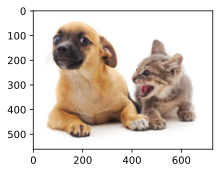

In [ ]:
d2l.set_figsize()
img = d2l.plt.imread('../img/catdog.jpg')
d2l.plt.imshow(img);

In [ ]:
#@save
def box_corner_to_center(boxes):
    """Convert from (upper-left, lower-right) to (center, width, height)."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes

#@save
def box_center_to_corner(boxes):
    """Convert from (center, width, height) to (upper-left, lower-right)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

In [ ]:
# Here `bbox` is the abbreviation for bounding box
dog_bbox, cat_bbox = [60.0, 45.0, 378.0, 516.0], [400.0, 112.0, 655.0, 493.0]

In [ ]:
boxes = torch.tensor((dog_bbox, cat_bbox))
box_center_to_corner(box_corner_to_center(boxes)) == boxes

tensor([[True, True, True, True],
        [True, True, True, True]])

In [ ]:
#@save
def bbox_to_rect(bbox, color):
    """Convert bounding box to matplotlib format."""
    # Convert the bounding box (upper-left x, upper-left y, lower-right x,
    # lower-right y) format to the matplotlib format: ((upper-left x,
    # upper-left y), width, height)
    return d2l.plt.Rectangle(
        xy=(bbox[0], bbox[1]), width=bbox[2]-bbox[0], height=bbox[3]-bbox[1],
        fill=False, edgecolor=color, linewidth=2)

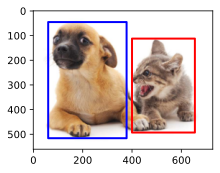

In [ ]:
fig = d2l.plt.imshow(img)
fig.axes.add_patch(bbox_to_rect(dog_bbox, 'blue'))
fig.axes.add_patch(bbox_to_rect(cat_bbox, 'red'));

================================= Anchor Boxes =================================

### Why Anchor Boxes?

Object detection requires predicting bounding boxes. Instead of predicting boxes from scratch, most detectors generate a large set of **anchor boxes** (prior boxes) and then:

> **Side note (Anchor boxes vs Bounding boxes):**
- **Anchor boxes** are predefined template/reference boxes at different scales and aspect ratios.
- **Bounding boxes** are the actual object boxes (ground-truth labels or final model predictions).
- Intuition: anchor box = starting guess; bounding box = final object location.

1. **Classify** each anchor as containing an object or background.
2. **Refine** the anchor's position to better fit the object (offset regression).

### Generating Anchor Boxes

Anchors are centered at each pixel and generated with multiple **scales** $s \in (0, 1]$ and **aspect ratios** $r > 0$ (ratio of width to height). For an input image with height $h$ and width $w$:

$$\text{box width} = w \cdot s \cdot \sqrt{r}, \quad \text{box height} = h \cdot s / \sqrt{r}$$

For $n$ scales and $m$ ratios, we generate $n + m - 1$ anchors per pixel (not $n \times m$, to avoid redundancy):
- All scales with the first ratio: $(s_1, r_1), (s_2, r_1), \ldots, (s_n, r_1)$
- All ratios with the first scale: $(s_1, r_2), (s_1, r_3), \ldots, (s_1, r_m)$

For an $h \times w$ image: total anchors = $h \times w \times (n + m - 1)$.

### Intersection over Union (IoU)

IoU (Jaccard index) measures how well two boxes overlap:

$$J(\mathcal{A}, \mathcal{B}) = \frac{|\mathcal{A} \cap \mathcal{B}|}{|\mathcal{A} \cup \mathcal{B}|}$$

- $\text{IoU} = 0$: no overlap
- $\text{IoU} = 1$: perfect overlap
- Typically, an anchor is considered a **positive match** if IoU ≥ 0.5 with a ground-truth box.

### Assigning Ground-Truth to Anchors

This step is used during **training target generation** (label creation), not during final prediction.

Given $n_a$ anchors and $n_b$ ground-truth boxes, build an IoU matrix
$$\mathbf{X} \in \mathbb{R}^{n_a \times n_b}, \quad x_{ij} = \text{IoU}(\text{anchor}_i, \text{gt}_j).$$

D2L-style assignment returns an anchor-to-gt map:
- Output: a vector `anchors_bbox_map` of length $n_a$.
- `anchors_bbox_map[i] = j` means anchor $i$ is matched to gt $j$.
- `anchors_bbox_map[i] = -1` means anchor $i$ is background.

It is built in two passes:

1. **Threshold pass (anchor perspective)**
- For each anchor $i$, find one best gt: $j^* = \arg\max_j x_{ij}$.
- If $x_{i j^*} \ge \tau$ (often $\tau=0.5$), set `anchors_bbox_map[i] = j^*`.
- Else set `anchors_bbox_map[i] = -1` for now.
- Result of this pass: **each anchor is assigned to at most one gt**.

2. **Guarantee pass (ground-truth perspective)**
- Some gt boxes may still have no anchor after pass 1.
- Repeatedly pick the largest remaining IoU in $\mathbf{X}$, match that anchor-gt pair, then invalidate that anchor row and gt column.
- Continue until every gt has at least one matched anchor.
- Result of this pass: **each gt is assigned by at least one anchor**.

Final properties of the output:
- Anchor side: one anchor maps to at most one gt (or background).
- GT side: one gt can be matched by multiple anchors.
- Matched anchors are positives (use matched class label); unmatched anchors are background.

### Offset Prediction

Rather than predicting absolute box coordinates, the model predicts **offsets** from the anchor:

$$\hat{x} = (x - x_a) / w_a, \quad \hat{y} = (y - y_a) / h_a$$
$$\hat{w} = \log(w / w_a), \quad \hat{h} = \log(h / h_a)$$

where $(x_a, y_a, w_a, h_a)$ is the anchor and $(x, y, w, h)$ is the target.

### Non-Maximum Suppression (NMS)

NMS is used during **prediction/inference** after the model outputs many candidate boxes and scores.

Multiple anchors may predict overlapping boxes for the same object. **NMS** removes redundant predictions:

1. Sort predictions by confidence score.
2. Keep the top prediction; remove all predictions with IoU > threshold (e.g., 0.5) with it.
3. Repeat for remaining predictions.

### Key Takeaways

- **Anchor boxes** are predefined reference boxes that simplify detection by converting it into classification + regression.
- **IoU** is the standard metric for measuring bounding box overlap.
- Assignment should consider both anchor-wise thresholding and gt-wise best-match guarantees.
- **Offset regression** is more stable than directly predicting coordinates.
- **NMS** is essential post-processing to eliminate duplicate detections.

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

torch.set_printoptions(2)  # Simplify printing accuracy

In [2]:
#@save
def multibox_prior(data, sizes, ratios):
    """Generate anchor boxes with different shapes centered on each pixel."""
    # ------------------------------------------------------------------
    # 1) Read spatial size and prepare basic constants
    # ------------------------------------------------------------------
    in_height, in_width = data.shape[-2:]
    device = data.device
    num_sizes, num_ratios = len(sizes), len(ratios)
    boxes_per_pixel = num_sizes + num_ratios - 1
    
    # Convert Python lists to tensors on the same device as input
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)
    
    # ------------------------------------------------------------------
    # 2) Build normalized center coordinates for every pixel
    # ------------------------------------------------------------------
    # Each pixel center is shifted by 0.5 in pixel coordinates.
    # After scaling by step size, centers are in [0, 1].
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height
    steps_w = 1.0 / in_width
    
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    
    # Meshgrid gives all (y, x) center pairs for the full feature map.
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)
    
    # ------------------------------------------------------------------
    # 3) Build anchor widths/heights for one pixel
    # ------------------------------------------------------------------
    # D2L uses (n + m - 1) anchors per pixel:
    # - all sizes with first ratio
    # - first size with remaining ratios
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),
                   sizes[0] * torch.sqrt(ratio_tensor[1:])))
    # Correct width for non-square feature maps in normalized coordinates.
    w = w * in_height / in_width
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))
    
    # Convert (w, h) to corner offsets from center: (-w/2, -h/2, w/2, h/2)
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
        in_height * in_width, 1) / 2
    
    # ------------------------------------------------------------------
    # 4) Tile centers and add offsets to get final anchors
    # ------------------------------------------------------------------
    # For each center, repeat it `boxes_per_pixel` times so shapes align.
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1)
    out_grid = out_grid.repeat_interleave(boxes_per_pixel, dim=0)
    
    # Final shape before batch dim:
    # (in_height * in_width * boxes_per_pixel, 4)
    output = out_grid + anchor_manipulations
    
    # Add batch dimension to match downstream API: (1, num_anchors, 4)
    return output.unsqueeze(0)

In [3]:
img = d2l.plt.imread('../img/catdog.jpg')
h, w = img.shape[:2]

print(h, w)
X = torch.rand(size=(1, 3, h, w))  # Construct input data
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape # (batch size, number of anchor boxes, 4) number of anchor boxes = 561*728*(3+3-1)

561 728


torch.Size([1, 2042040, 4])

In [4]:
boxes = Y.reshape(h, w, 5, 4)
boxes[250, 250, 0, :]

tensor([0.06, 0.07, 0.63, 0.82])

In [7]:
#@save
def show_bboxes(axes, bboxes, labels=None, colors=None):
    """Show bounding boxes."""

    def make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = make_list(labels)
    print(labels)
    colors = make_list(colors, ['b', 'g', 'r', 'm', 'c'])
    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = d2l.bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w'
            axes.text(rect.xy[0], rect.xy[1], labels[i],
                      va='center', ha='center', fontsize=9, color=text_color,
                      bbox=dict(facecolor=color, lw=0))

['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2', 's=0.75, r=0.5']


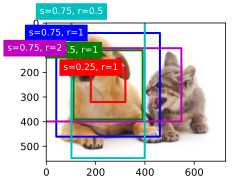

In [8]:
d2l.set_figsize()
bbox_scale = torch.tensor((w, h, w, h))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[250, 250, :, :] * bbox_scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2', 's=0.75, r=0.5'])

In [10]:
#@save
def box_iou(boxes1, boxes2):
    """Compute pairwise IoU across two lists of anchor or bounding boxes."""
    # ------------------------------------------------------------------
    # 1) Box areas for each set independently
    # ------------------------------------------------------------------
    # boxes format: (x_min, y_min, x_max, y_max)
    # boxes1 shape: (n1, 4), boxes2 shape: (n2, 4)
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))
    areas1 = box_area(boxes1)  # (n1,)
    areas2 = box_area(boxes2)  # (n2,)
    
    # ------------------------------------------------------------------
    # 2) Pairwise intersection rectangle (broadcast over n1 x n2)
    # ------------------------------------------------------------------
    # Top-left corner of intersection: max of top-left corners
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    # Bottom-right corner of intersection: min of bottom-right corners
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    
    # Width/height of intersection; clamp negatives to 0 (no overlap case)
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)  # (n1, n2, 2)
    
    # ------------------------------------------------------------------
    # 3) Pairwise intersection and union areas
    # ------------------------------------------------------------------
    inter_areas = inters[:, :, 0] * inters[:, :, 1]  # (n1, n2)
    union_areas = areas1[:, None] + areas2 - inter_areas  # (n1, n2)
    
    # ------------------------------------------------------------------
    # 4) IoU = intersection / union for every (box1_i, box2_j) pair
    # ------------------------------------------------------------------
    return inter_areas / union_areas

In [11]:
#@save
def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """Assign closest ground-truth bounding boxes to anchor boxes."""
    # ------------------------------------------------------------------
    # 1) Basic sizes and IoU matrix
    # ------------------------------------------------------------------
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    # jaccard[i, j] = IoU(anchor_i, gt_j), shape: (num_anchors, num_gt_boxes)
    jaccard = box_iou(anchors, ground_truth)
    
    # Output map (length = num_anchors):
    # -1 means background; non-negative value means matched gt index
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,
                                  device=device)
    
    # ------------------------------------------------------------------
    # 2) Pass A: anchor-wise threshold matching
    # ------------------------------------------------------------------
    # For each anchor, keep its best gt. If IoU >= threshold, mark as positive.
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    box_j = indices[max_ious >= iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    
    # ------------------------------------------------------------------
    # 3) Pass B: gt-wise best-match guarantee
    # ------------------------------------------------------------------
    # Ensure every gt gets at least one anchor by repeatedly selecting the
    # current global max IoU pair, then removing its row/column from reuse.
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)  # Index in flattened IoU matrix
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx / num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard   # Invalidate this gt column
        jaccard[anc_idx, :] = row_discard   # Invalidate this anchor row
    
    # Final result: anchor -> matched gt index, or -1 for background
    return anchors_bbox_map

In [12]:
#@save
def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """Transform for anchor box offsets."""
    c_anc = d2l.box_corner_to_center(anchors)
    c_assigned_bb = d2l.box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset

In [13]:
#@save
def multibox_target(anchors, labels):
    """Label anchor boxes using ground-truth bounding boxes."""
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(
            label[:, 1:], anchors, device)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(
            1, 4)
        # Initialize class labels and assigned bounding box coordinates with
        # zeros
        class_labels = torch.zeros(num_anchors, dtype=torch.long,
                                   device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32,
                                  device=device)
        # Label classes of anchor boxes using their assigned ground-truth
        # bounding boxes. If an anchor box is not assigned any, we label its
        # class as background (the value remains zero)
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        # Offset transformation
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    return (bbox_offset, bbox_mask, class_labels)

['dog', 'cat']
['0', '1', '2', '3', '4']


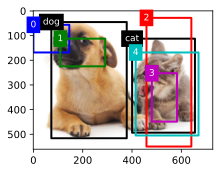

In [14]:
ground_truth = torch.tensor([[0, 0.1, 0.08, 0.52, 0.92],
                         [1, 0.55, 0.2, 0.9, 0.88]])
anchors = torch.tensor([[0, 0.1, 0.2, 0.3], [0.15, 0.2, 0.4, 0.4],
                    [0.63, 0.05, 0.88, 0.98], [0.66, 0.45, 0.8, 0.8],
                    [0.57, 0.3, 0.92, 0.9]])

fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, ground_truth[:, 1:] * bbox_scale, ['dog', 'cat'], 'k')
show_bboxes(fig.axes, anchors * bbox_scale, ['0', '1', '2', '3', '4']);

In [16]:
labels = multibox_target(anchors.unsqueeze(dim=0), ground_truth.unsqueeze(dim=0))

In [17]:
labels[2]

tensor([[0, 1, 2, 0, 2]])

In [18]:
labels[1]

tensor([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1.,
         1., 1.]])

In [19]:
labels[0]

tensor([[-0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00,  1.40e+00,  1.00e+01,
          2.59e+00,  7.18e+00, -1.20e+00,  2.69e-01,  1.68e+00, -1.57e+00,
         -0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00, -5.71e-01, -1.00e+00,
          4.17e-06,  6.26e-01]])

In [20]:
#@save
def offset_inverse(anchors, offset_preds):
    """Predict bounding boxes based on anchor boxes with predicted offsets."""
    anc = d2l.box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = d2l.box_center_to_corner(pred_bbox)
    return predicted_bbox

In [21]:
#@save
def nms(boxes, scores, iou_threshold):
    """Sort confidence scores of predicted bounding boxes."""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # Indices of predicted bounding boxes that will be kept
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device)

In [22]:
#@save
def multibox_detection(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                       pos_threshold=0.009999999):
    """Predict bounding boxes using non-maximum suppression."""
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse(anchors, offset_pred)
        keep = nms(predicted_bb, conf, nms_threshold)
        # Find all non-`keep` indices and set the class to background
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        # Here `pos_threshold` is a threshold for positive (non-background)
        # predictions
        below_min_idx = (conf < pos_threshold)
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

In [23]:
anchors = torch.tensor([[0.1, 0.08, 0.52, 0.92], [0.08, 0.2, 0.56, 0.95],
                      [0.15, 0.3, 0.62, 0.91], [0.55, 0.2, 0.9, 0.88]])
offset_preds = torch.tensor([0] * anchors.numel())
cls_probs = torch.tensor([[0] * 4,  # Predicted background likelihood
                      [0.9, 0.8, 0.7, 0.1],  # Predicted dog likelihood
                      [0.1, 0.2, 0.3, 0.9]])  # Predicted cat likelihood

['dog=0.9', 'dog=0.8', 'dog=0.7', 'cat=0.9']


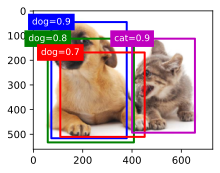

In [24]:
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, anchors * bbox_scale,
            ['dog=0.9', 'dog=0.8', 'dog=0.7', 'cat=0.9'])

In [25]:
output = multibox_detection(cls_probs.unsqueeze(dim=0),
                            offset_preds.unsqueeze(dim=0),
                            anchors.unsqueeze(dim=0),
                            nms_threshold=0.5)
output

tensor([[[ 0.00,  0.90,  0.10,  0.08,  0.52,  0.92],
         [ 1.00,  0.90,  0.55,  0.20,  0.90,  0.88],
         [-1.00,  0.80,  0.08,  0.20,  0.56,  0.95],
         [-1.00,  0.70,  0.15,  0.30,  0.62,  0.91]]])

['dog=0.9']
['cat=0.9']


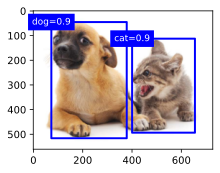

In [26]:
fig = d2l.plt.imshow(img)
for i in output[0].detach().numpy():
    if i[0] == -1:
        continue
    label = ('dog=', 'cat=')[int(i[0])] + str(i[1])
    show_bboxes(fig.axes, [torch.tensor(i[2:]) * bbox_scale], label)

================================ Multiscale Object Detection ================================

## Multiscale Object Detection

### Why Different Scales Matter

Objects in the same image can appear at very different sizes (tiny when far away, large when close).
A single feature-map resolution is not enough:

- A coarse map can miss small objects.
- A fine map is computationally expensive and inefficient for very large objects.

Modern detectors therefore use **multiscale feature maps** (a feature pyramid), not just one map.

### What "Scale" Means Here

In this context, **scale** means the spatial resolution of a feature map (for example, $64\times64$, $32\times32$, $16\times16$).

- Larger spatial maps (more grid cells): better for small objects.
- Smaller spatial maps (fewer grid cells): better for large objects.
- Channel count may change too, but detection "scale" mainly refers to spatial size and receptive field.

A feature map shape is `(channels, height, width)`:

- `channels`: number of learned feature channels
- `(height, width)`: spatial grid used for localization

Example: `(64, 4, 4)` means 64 channels and a $4\times4$ grid (16 positions).
This is different from image size.

Think of a $4\times4$ feature map as a coarse grid over the image:

- Each grid cell is one anchor-center location.
- Larger maps provide denser centers and finer localization.
- Smaller maps provide fewer centers but stronger large-context features.

### Feature Pyramid / Multiscale Detection

Anchors and predictions are generated at multiple feature-map scales:

| Feature map scale | Best for | Why |
|---|---|---|
| Fine scale (early / high-res map) | Small objects | Dense locations, finer localization |
| Medium scale | Medium objects | Balanced detail and context |
| Coarse scale (deep / low-res map) | Large objects | Larger receptive field, broader context |

At each scale:

- The feature map has spatial size $h \times w$.
- Each location generates anchors with different sizes and ratios.
- The model predicts class scores and box offsets per anchor.

### How Shared Multiscale Maps Are Computed

For an input image and a CNN backbone:

```
Input image (for example 256x256)
  -> Backbone conv/pool blocks
  -> Feature maps at multiple stages (for example 64x64, 32x32, 16x16, 8x8)
  -> (Optional but common) FPN top-down + lateral fusion
  -> Final pyramid levels used by detection heads
```

Why this helps:

- Lower layers preserve detail for tiny objects.
- Higher layers provide stronger semantics and larger context for big objects.
- FPN combines both so each pyramid level becomes more useful.

Note: The concept of a **shared feature map** is explained in detail later in the **Region-based CNNs (Fast R-CNN)** section.

### Key Takeaways

- "Scale" mainly refers to feature-map spatial resolution (and its receptive field).
- Multiscale detection is necessary because object sizes vary widely in real images.
- High-resolution maps help small objects; low-resolution maps help large objects.
- This section directly connects to FPN-style design in both one-stage and two-stage detectors.

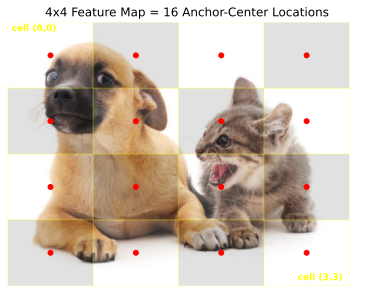

In [33]:
# Visualize a 4x4 feature-map grid as a coarse chessboard over the image.
import matplotlib.patches as patches

def draw_feature_map_chessboard(img, fmap_h=4, fmap_w=4):
    d2l.set_figsize((7, 5))
    fig, ax = d2l.plt.subplots()
    ax.imshow(img)

    img_h, img_w = img.shape[:2]
    cell_h = img_h / fmap_h
    cell_w = img_w / fmap_w

    # Draw checkerboard cells and center points (anchor-center locations).
    for r in range(fmap_h):
        for c in range(fmap_w):
            x0, y0 = c * cell_w, r * cell_h
            color = 'white' if (r + c) % 2 == 0 else 'black'
            rect = patches.Rectangle(
                (x0, y0), cell_w, cell_h,
                facecolor=color, alpha=0.12, edgecolor='yellow', linewidth=1.5
            )
            ax.add_patch(rect)

            cx = (c + 0.5) * cell_w
            cy = (r + 0.5) * cell_h
            ax.plot(cx, cy, marker='o', color='red', markersize=5)

    # Label a few cells to emphasize the mapping from feature-map index to image region.
    ax.text(8, 18, 'cell (0,0)', color='yellow', fontsize=9, weight='bold')
    ax.text(img_w - 110, img_h - 12, f'cell ({fmap_h-1},{fmap_w-1})',
            color='yellow', fontsize=9, weight='bold')

    ax.set_title(f'{fmap_h}x{fmap_w} Feature Map = {fmap_h*fmap_w} Anchor-Center Locations')
    ax.axis('off')
    d2l.plt.show()

draw_feature_map_chessboard(img, fmap_h=4, fmap_w=4)

In [27]:
%matplotlib inline
import torch
from d2l import torch as d2l

img = d2l.plt.imread('../img/catdog.jpg')
h, w = img.shape[:2]
h, w

(561, 728)

In [ ]:
def display_anchors(fmap_w, fmap_h, s):
    d2l.set_figsize()
    # `fmap_h`/`fmap_w` control feature-map grid resolution only.
    # They do NOT change the original image size used for visualization.
    fmap = torch.zeros((1, 10, fmap_h, fmap_w))
    anchors = d2l.multibox_prior(fmap, sizes=s, ratios=[1, 2, 0.5])
    bbox_scale = torch.tensor((w, h, w, h))
    d2l.show_bboxes(d2l.plt.imshow(img).axes, anchors[0] * bbox_scale)

In [1]:
# Here 4x4 refers to FEATURE MAP resolution, not image pixel size.
# So we have 16 center locations on the feature map.
# With s=[0.15] and ratios [1, 2, 0.5], anchors per location = 3.
# Total anchors drawn = 4 * 4 * 3 = 48.
display_anchors(fmap_w=4, fmap_h=4, s=[0.15])

# When you call above:
# - `fmap_w=4, fmap_h=4` is feature map resolution, not image pixel size.
# - The original image is still full resolution (for `catdog.jpg`, about 561 * 728).
# - Each feature-map location corresponds to a region in the original image.
# - With ratios `[1, 2, 0.5]`, anchors per location = $1 + 3 - 1 = 3$.

# Total anchors in this example:
# $4 * 4 * 3 = 48.$

NameError: name 'display_anchors' is not defined

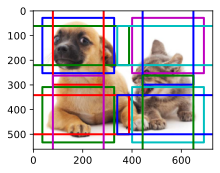

In [ ]:
# We move on to reduce the height and width of the feature map by half and use larger 
# anchor boxes to detect larger objects. When the scale is set to 0.4, some anchor 
# boxes will overlap with each other.

display_anchors(fmap_w=2, fmap_h=2, s=[0.4])

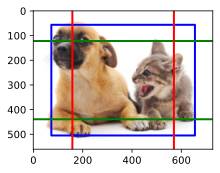

In [30]:
display_anchors(fmap_w=1, fmap_h=1, s=[0.8])

================================ The Object Detection Dataset ================================

### Overview

This section introduces a small **banana detection dataset** used as a pedagogical example, along with data loading utilities for object detection.

### Dataset Format

Each training example consists of:
- An **image** ($3 \times 256 \times 256$)
- **Labels**: a tensor of shape $(m, 5)$ where $m$ is the number of objects, and each row is:
  - `[class_label, x_min, y_min, x_max, y_max]`
  - Bounding box coordinates are **normalized** to $[0, 1]$ (relative to image size)

### Data Loading for Detection

Unlike classification (one label per image), detection requires:
- Variable numbers of objects per image → labels are **padded** to a fixed maximum.
- Bounding boxes must be **transformed** alongside images during augmentation (e.g., if an image is flipped, boxes flip too).

In [34]:
%matplotlib inline
import os
import pandas as pd
import torch
import torchvision
from d2l import torch as d2l

#@save
d2l.DATA_HUB['banana-detection'] = (
    d2l.DATA_URL + 'banana-detection.zip',
    '5de26c8fce5ccdea9f91267273464dc968d20d72')

In [35]:
#@save
def read_data_bananas(is_train=True):
    """Read the banana detection dataset images and labels."""
    data_dir = d2l.download_extract('banana-detection')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        # Here `target` contains (class, upper-left x, upper-left y,
        # lower-right x, lower-right y), where all the images have the same
        # banana class (index 0)
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

In [36]:
#@save
class BananasDataset(torch.utils.data.Dataset):
    """A customized dataset to load the banana detection dataset."""
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

In [37]:
#@save
def load_data_bananas(batch_size):
    """Load the banana detection dataset."""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

In [38]:
batch_size, edge_size = 32, 256
train_iter, _ = load_data_bananas(batch_size)
batch = next(iter(train_iter))
batch[0].shape, batch[1].shape

read 1000 training examples
read 100 validation examples


(torch.Size([32, 3, 256, 256]), torch.Size([32, 1, 5]))

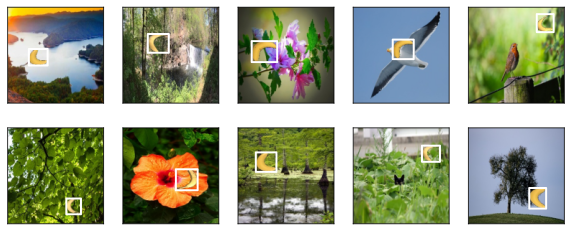

In [39]:
imgs = (batch[0][:10].permute(0, 2, 3, 1)) / 255
axes = d2l.show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][:10]):
    d2l.show_bboxes(ax, [label[0][1:5] * edge_size], colors=['w'])

================================= Single Shot Multibox Detection =================================

### Overview

**SSD** (Single Shot Multibox Detection) is an end-to-end object detection model that predicts bounding boxes and class labels in a **single forward pass** (single-stage), without a separate proposal stage like Faster R-CNN.

### Architecture Flow (Clear View)

```
Input image (256x256)
  -> Base network (truncated VGG/ResNet backbone)
     -> outputs deeper channels + smaller spatial map

  -> Extra multiscale feature blocks
     -> progressively downsample spatial resolution
     -> produce feature pyramid: 32x32 -> 16x16 -> 8x8 -> 4x4 -> 1x1

  -> For each selected feature map level (parallel heads)
     -> Anchor generation on that feature grid
     -> Class prediction head (Conv2D) for each anchor
     -> Box-offset prediction head (Conv2D) for each anchor

  -> Concatenate outputs from all scales
     -> all anchors
     -> all class logits
     -> all box offsets

  -> Inference post-processing
     -> decode offsets to boxes
     -> confidence thresholding
     -> NMS
     -> final detections
```

!["Single Shot Multibox detection"](./Images/14/SSD.png)

### Key Clarification

- The **base network** extracts semantic features and already reduces spatial resolution while increasing channel depth.
- The **multiscale blocks** further downsample, producing smaller and smaller feature maps for larger-object context.
- The small prediction Conv2D heads are usually stride 1, so they generally **keep each selected feature map size**.
- Anchor generation is performed **on each final prediction feature map**, not on the raw input image.

### Key Components

#### 1. Base Network
- Extracts features from the input image.
- Typically a pretrained backbone (VGG, ResNet) truncated before classification layers.
- Outputs a feature map (e.g., $32 \times 32$).

#### 2. Multiscale Feature Blocks
- Each block usually halves spatial resolution (via stride-2 conv or pooling).
- Produces a hierarchy of feature maps for detecting objects at different scales.
- Example: $32 \times 32 \to 16 \times 16 \to 8 \times 8 \to 4 \times 4 \to 1 \times 1$.

#### 3. Prediction Layers (per scale)

| Layer | Output Shape | Purpose |
|---|---|---|
| **Class prediction** | $h \times w \times a(q+1)$ | Predict class for each of $a$ anchors ($q$ classes + background) |
| **Bbox prediction** | $h \times w \times 4a$ | Predict 4 offsets for each anchor |

where $a = n_{\text{sizes}} + n_{\text{ratios}} - 1$ anchors per pixel.

#### 4. Training

**Loss function** combines:

$$\mathcal{L} = \mathcal{L}_{\text{cls}}(\text{class predictions}, \text{labels}) + \lambda \cdot \mathcal{L}_{\text{bbox}}(\text{offset predictions}, \text{offsets})$$

- $\mathcal{L}_{\text{cls}}$: Cross-entropy loss for classification.
- $\mathcal{L}_{\text{bbox}}$: $L_1$ loss for bounding box offsets (only for non-background anchors).

#### 5. Prediction / Inference

1. Forward pass -> class scores + offsets for all anchors at all scales.
2. Apply offsets to anchor boxes -> predicted bounding boxes.
3. Filter out low-confidence predictions.
4. Apply **NMS** per class to remove duplicates.

### Key Takeaways

- SSD is a **single-stage** detector: fast and end-to-end trainable.
- Flow is: **backbone -> multiscale downsampling blocks -> per-scale anchors and prediction heads -> concatenate -> decode -> NMS**.
- Multiscale feature maps enable detection of objects at various sizes.
- Each spatial position at each scale predicts classes and box offsets for multiple anchors.
- SSD trades some accuracy for significant speed advantages over many two-stage detectors.

In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

# Class prediction head: for each anchor at each pixel, output
# (num_classes + 1) logits (including background).
def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(in_channels=num_inputs,
                     out_channels=num_anchors * (num_classes + 1),
                     kernel_size=3,
                     padding=1)

In [ ]:
# Bounding-box head: for each anchor, predict 4 offsets (dx, dy, dw, dh).
def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(
        in_channels=num_inputs,
        out_channels=num_anchors * 4,
        kernel_size=3,
        padding=1)

In [ ]:
# Helper for testing a module with an input tensor.
def forward(x, block):
    return block(x)

# Verify class head output shapes on two feature-map resolutions.
# SSD predicts on multiple scales, so HxW can differ by level.
# Y1 = (batch_size=2, channels=8, height=20, width=20) pass block: nn.Conv2d(8, 55, kernel_size = 3, padding=1)
# Y2 = (batch_size=2, channels=16, height=10, width=10) pass block: nn.Conv2d(16, 33, kernel_size = 3, padding=1)
Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(num_inputs=8, num_anchors=5, num_classes=10))
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(num_inputs=16, num_anchors=3, num_classes=10))
Y1.shape, Y2.shape
# Output shape format is (batch_size, channels, height, width).

In [ ]:
# Move channel dimension to the end and flatten each prediction map
# into shape: (batch size, height * width * number of channels)
def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

# Concatenate predictions from all scales along the position dimension.
def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

In [ ]:
# After flattening, predictions from two scales are concatenated.
concat_preds([Y1, Y2]).shape

In [ ]:
# A downsampling block used by TinySSD:
# 2x (Conv-BN-ReLU) followed by 2x spatial downsampling via MaxPool.
def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels,
                             kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)

In [ ]:
# Check that the block halves H and W: 20x20 -> 10x10.
forward(torch.zeros((2, 3, 20, 20)), down_sample_blk(3, 10)).shape

In [ ]:
# Base feature extractor: stack several downsampling blocks.
# For a 256x256 input, this outputs a coarser feature map for SSD heads.
def base_net():
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i+1]))
    return nn.Sequential(*blk)

forward(torch.zeros((2, 3, 256, 256)), base_net()).shape

In [ ]:
# Build the i-th feature block in TinySSD.
# i=0: base network, i=1..3: extra downsampling blocks, i=4: global pooling.
def get_blk(i):
    if i == 0:
        blk = base_net()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        blk = nn.AdaptiveMaxPool2d((1,1))
    else:
        blk = down_sample_blk(128, 128)
    return blk

In [ ]:
# One SSD forward step at a single scale:
# 1) extract features, 2) generate anchors, 3) predict class logits and box offsets.
def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    Y = blk(X)
    anchors = d2l.multibox_prior(Y, sizes=size, ratios=ratio)
    cls_preds = cls_predictor(Y)
    bbox_preds = bbox_predictor(Y)
    return (Y, anchors, cls_preds, bbox_preds)

In [ ]:
# Anchor box scales for the 5 prediction levels (from small to large).
sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79],
         [0.88, 0.961]]
# Aspect ratios used at each level (same ratios for simplicity).
ratios = [[1, 2, 0.5]] * 5
# Anchors per pixel = len(sizes[level]) + len(ratios[level]) - 1
num_anchors = len(sizes[0]) + len(ratios[0]) - 1

In [ ]:
class TinySSD(nn.Module):
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        # Build 5 feature levels; each has a feature block plus two prediction heads.
        for i in range(5):
            # Equivalent to the assignment statement `self.blk_i = get_blk(i)`
            setattr(self, f'blk_{i}', get_blk(i))
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i],
                                                    num_anchors, num_classes))
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i],
                                                      num_anchors))

    def forward(self, X):
        # Collect anchors, class predictions, and bbox predictions from all scales.
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            # Here `getattr(self, 'blk_%d' % i)` accesses `self.blk_i`
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X, getattr(self, f'blk_{i}'), sizes[i], ratios[i],
                getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
        # Concatenate multiscale outputs into unified tensors.
        anchors = torch.cat(anchors, dim=1)
        cls_preds = concat_preds(cls_preds)
        cls_preds = cls_preds.reshape(
            cls_preds.shape[0], -1, self.num_classes + 1)
        bbox_preds = concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds

In [ ]:
# Load the banana detection dataset used to train TinySSD.
batch_size = 32
train_iter, _ = d2l.load_data_bananas(batch_size)

In [ ]:
# Initialize model and optimizer (SGD + weight decay) as in D2L's SSD example.
device, net = d2l.try_gpu(), TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

In [ ]:
# SSD uses a sum of classification loss and box regression loss.
cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = nn.L1Loss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    # Classification: average over all anchors per image.
    cls = cls_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    # Box regression: only positive anchors contribute via bbox_masks.
    bbox = bbox_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks).mean(dim=1)
    return cls + bbox

In [ ]:
def cls_eval(cls_preds, cls_labels):
    # Class prediction logits are on the last dimension, so take argmax there.
    return float((cls_preds.argmax(dim=-1).type(
        cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    # Absolute offset error on positive anchors only (masked).
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

In [ ]:
num_epochs, timer = 20, d2l.Timer()
animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                        legend=['class error', 'bbox mae'])
net = net.to(device)
for epoch in range(num_epochs):
    # Metrics tracked over one epoch:
    # (correct class predictions, total class labels, sum bbox abs error, total bbox terms).
    metric = d2l.Accumulator(4)
    net.train()
    for features, target in train_iter:
        timer.start()
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # Forward pass: generate anchors and predict class logits + box offsets.
        anchors, cls_preds, bbox_preds = net(X)
        # Match anchors with ground truth and produce training targets.
        bbox_labels, bbox_masks, cls_labels = d2l.multibox_target(anchors, Y)
        # Compute SSD loss = classification loss + localization loss.
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels,
                      bbox_masks)
        l.mean().backward()
        trainer.step()
        # Update running metrics for plotting and final report.
        metric.add(cls_eval(cls_preds, cls_labels), cls_labels.numel(),
                   bbox_eval(bbox_preds, bbox_labels, bbox_masks),
                   bbox_labels.numel())
    cls_err, bbox_mae = 1 - metric[0] / metric[1], metric[2] / metric[3]
    animator.add(epoch + 1, (cls_err, bbox_mae))
print(f'class err {cls_err:.2e}, bbox mae {bbox_mae:.2e}')
print(f'{len(train_iter.dataset) / timer.stop():.1f} examples/sec on '
      f'{str(device)}')

In [ ]:
# Load a test image and convert it to HWC format for visualization.
X = torchvision.io.read_image('../img/banana.jpg').unsqueeze(0).float()
img = X.squeeze(0).permute(1, 2, 0).long()

In [ ]:
def predict(X):
    # Switch to eval mode to disable training-specific layers/behavior.
    net.eval()
    anchors, cls_preds, bbox_preds = net(X.to(device))
    # Convert class logits to probabilities and run SSD post-processing (incl. NMS).
    cls_probs = F.softmax(cls_preds, dim=2).permute(0, 2, 1)
    output = d2l.multibox_detection(cls_probs, bbox_preds, anchors)
    # Keep only valid detections (class id != -1).
    idx = [i for i, row in enumerate(output[0]) if row[0] != -1]
    return output[0, idx]

output = predict(X)

In [ ]:
def display(img, output, threshold):
    d2l.set_figsize((5, 5))
    fig = d2l.plt.imshow(img)
    for row in output:
        score = float(row[1])
        # Filter out low-confidence detections.
        if score < threshold:
            continue
        # Convert normalized bbox coordinates back to pixel coordinates.
        h, w = img.shape[:2]
        bbox = [row[2:6] * torch.tensor((w, h, w, h), device=row.device)]
        d2l.show_bboxes(fig.axes, bbox, '%.2f' % score, 'w')

display(img, output.cpu(), threshold=0.9)

================ Region-based CNNs (R-CNNs) ================

### Shared Feature Map vs Feature Pyramid (Quick Clarification)

These ideas are related, but they are not the same thing:

- **Shared feature map**: RoIs/proposals reuse backbone features, instead of running a full CNN for each proposal.
- **Feature pyramid**: the detector uses multiple shared feature maps at different resolutions.

Relationship summary:

- Shared feature map is the broader compute-sharing idea.
- Feature pyramid is a multiscale implementation of shared features.
- A detector may use one shared map (single-scale) or a shared set of maps (multiscale).

Why this matters in Chapter 14:

- In classic **Fast R-CNN**, explanation usually starts with one shared feature map.
- In modern detectors, this often extends to shared multiscale pyramids (for example FPN levels $P_3, P_4, P_5, P_6, P_7$).

### Overview

Region-based CNNs are **two-stage** detectors:

1. Propose candidate regions.
2. Classify each region and refine its box.

This family includes **R-CNN**, **Fast R-CNN**, and **Faster R-CNN**.

### Evolution of the R-CNN Family

#### 1) R-CNN (Girshick et al., 2014)

```
Input Image
    ↓
Selective Search -> ~2000 Region Proposals
    ↓ for each proposal:
    Warp to fixed size -> CNN (pretrained) -> Feature Vector
    ↓
    SVM Classifier + Bounding Box Regressor
```

**Selective Search** is a hand-crafted classical computer-vision proposal method. It groups superpixels using cues such as color, texture, size, and shape compatibility to produce category-agnostic candidate boxes.

!["R-CNN"](./Images/14/R-CNN.png)

**Main limitations:**

- Very slow (CNN forward pass repeated for about 2000 proposals per image).
- Multi-stage training pipeline.

#### 2) Fast R-CNN (Girshick, 2015)

```
Input Image -> CNN -> Full Feature Map (computed ONCE)
    ↓
Selective Search -> Region Proposals
    ↓
RoI Pooling (extract fixed-size features from the shared feature map)
    ↓
FC layers -> Class Prediction + Bbox Regression
```

**Critical clarification:**

- **Selective Search does NOT generate the shared feature map.**
- The **CNN backbone** generates one shared feature map for the whole image.
- **Selective Search** only provides proposal boxes (RoIs) in image coordinates.
- **RoI Pooling** maps those RoIs onto the shared feature map and pools fixed-size features.
- This shared-map reuse is the key speedup over R-CNN.

**What this means in practice (Fast R-CNN):**

- The shared feature map is usually smaller than the input image due to backbone downsampling (often around $16\times$ stride).
- Proposal boxes are defined in image coordinates, then mapped to feature-map coordinates (equivalently using `spatial_scale = 1 / stride`).
- RoI Pooling splits each mapped proposal into an $H \times W$ grid (commonly $7 \times 7$), max-pools each bin, and outputs fixed-size features $H \times W \times C$.
- These fixed-size RoI features are fed to FC layers for class scores and bounding-box offsets.

!["Fast R-CNN"](./Images/14/fast%20R-CNN.png)

**Key innovation:** **RoI Pooling** extracts fixed-size features from variable-size proposals on a shared map.

- CNN runs once per image (major speed improvement).
- End-to-end training, except proposal generation (still Selective Search).

#### 3) Faster R-CNN (Ren et al., 2015)

```
Input Image -> CNN -> Shared Feature Map
    ↓
Region Proposal Network (RPN):
    |- Anchor generation at each position
    |- Binary classification (object vs background)
    \- Bbox regression (refine anchors)
    ↓
RoI Pooling -> FC -> Class + Bbox
```

!["Faster R-CNN"](./Images/14/faster%20R-CNN.png)

**Key innovation:** **Region Proposal Network (RPN)** replaces Selective Search with a learned proposal generator.

**What this means in practice (Faster R-CNN):**

- The backbone still computes one shared feature map for the image (or pyramid levels in modern variants).
- At each feature-map location, the RPN places multiple anchors and predicts:
  - Objectness score (object vs background)
  - Anchor-relative box offsets $(t_x, t_y, t_w, t_h)$
- Applying offsets to anchors yields proposal boxes; NMS keeps top proposals.
- Proposals are mapped to feature-map coordinates and sent to RoI Pooling (or RoIAlign in later models).
- RoI pooling/alignment converts each variable-size proposal into fixed-size features (commonly $7 \times 7 \times C$) for the detection head.
- The final head predicts per-proposal class scores plus second-stage box refinement, typically improving accuracy over single-stage regression.
- Localization is represented by anchor geometry + predicted offsets + RoI sampling, not by storing one offset code per region in the global feature map.

### Side-by-Side Comparison

| Component | R-CNN | Fast R-CNN | Faster R-CNN |
|---|---|---|---|
| **Proposals** | Selective Search | Selective Search | RPN (learned) |
| **CNN passes** | ~2000/image | 1/image | 1/image |
| **Training** | Multi-stage | End-to-end (almost) | Fully end-to-end |
| **Speed** | Very slow | Fast | Faster |

### Selective Search vs RPN

- **Selective Search**: hand-crafted, non-learned proposal method based on superpixel grouping cues (color, texture, size, shape).
- **RPN**: small learned network head on CNN features that predicts objectness and anchor offsets.

**Main differences:**

- **Method**: heuristic/non-learned vs learned/trainable.
- **Speed**: slower CPU-style preprocessing vs fast GPU-friendly in-network proposals.
- **Integration**: external algorithm vs integrated module sharing backbone features.
- **Adaptation**: fixed behavior vs improves during detector training.
- **Proposal quality tradeoff**: many generic proposals vs fewer task-relevant proposals.

### RoI Pooling Recap

RoI Pooling converts variable-size regions into fixed-size feature maps:

1. Divide each RoI into an $H \times W$ grid.
2. Max-pool inside each bin.
3. Output an $H \times W$ feature map regardless of RoI size.

### Key Takeaways

- Two-stage detectors (propose then classify) are usually strong in accuracy, especially in complex scenes.
- RoI Pooling enables heavy computation sharing across proposals.
- Faster R-CNN with RPN is a foundational design behind many modern variants (for example Mask R-CNN, Cascade R-CNN).
- Two-stage detectors are often more accurate but slower than single-stage detectors such as SSD and YOLO.

In [5]:
import torch
import torchvision

# Toy feature map: shape (N=1, C=1, H=4, W=4).
# Think of this as the CNN feature map (not the original image).
X = torch.arange(16.).reshape(1, 1, 4, 4)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

In [6]:
# RoI format: (batch_idx, x1, y1, x2, y2) in IMAGE coordinates.
# [0, 0, 0, 20, 20] means: use image 0 in the batch, box corners (0,0) -> (20,20).
# Region size in image coordinates is:
#   width  = x2 - x1 = 20 - 0 = 20
#   height = y2 - y1 = 20 - 0 = 20
# [0, 0, 10, 30, 30] is another box with width=30 and height=20.
rois = torch.Tensor([[0, 0, 0, 20, 20], [0, 0, 10, 30, 30]])

In [8]:
# RoI Pooling outputs a fixed 2x2 feature for each variable-size RoI.
# spatial_scale maps image coordinates -> feature-map coordinates.
# Here spatial_scale=0.1 means feature pixels are 10x coarser than image pixels.
# Example: (x1,y1,x2,y2)=(0,0,20,20) maps to about (0,0,2,2) on the 4x4 feature map.
#
## Why the first RoI output is [[5, 6], [9, 10]]:
# Feature map values are:
# [[ 0,  1,  2,  3],
#  [ 4,  5,  6,  7],
#  [ 8,  9, 10, 11],
#  [12, 13, 14, 15]]
#
# RoI Pooling divides the mapped RoI into a 2x2 grid and takes MAX in each bin:
# - top-left bin  -> max([[0,1],[4,5]])   = 5
# - top-right bin -> max([[1,2],[5,6]])   = 6
# - bot-left bin  -> max([[4,5],[8,9]])   = 9
# - bot-right bin -> max([[5,6],[9,10]])  = 10
# So pooled output = [[5, 6], [9, 10]].
#
## Why the second RoI output is [[9, 11], [13, 15]]:
# Second RoI is [0, 0, 10, 30, 30] -> mapped roughly to x:[0,3], y:[1,3].
# The 2x2 bins cover lower rows and wider columns, then max-pool per bin:
# - top-left bin  -> max over values around [[4,5],[8,9]]      = 9
# - top-right bin -> max over values around [[6,7],[10,11]]    = 11
# - bot-left bin  -> max over values around [[8,9],[12,13]]    = 13
# - bot-right bin -> max over values around [[10,11],[14,15]]  = 15
# So pooled output = [[9, 11], [13, 15]].
torchvision.ops.roi_pool(X, rois, output_size=(2, 2), spatial_scale=0.1)

tensor([[[[ 5.,  6.],
          [ 9., 10.]]],


        [[[ 9., 11.],
          [13., 15.]]]])

============================== Semantic Segmentation and the Dataset ==============================

### From Detection to Segmentation

| Task | Granularity | Output |
|---|---|---|
| **Image Classification** | Image-level | One label per image |
| **Object Detection** | Box-level | Bounding boxes + labels |
| **Semantic Segmentation** | Pixel-level | A class label for **every pixel** |
| **Instance Segmentation** | Pixel-level + instance | Class + instance ID per pixel |

### Semantic Segmentation

- Assign a **class label** to each pixel (e.g., road, car, person, sky).
- Unlike detection, there are **no bounding boxes** — the output is a dense label map the same size as the input.
- Applications: autonomous driving, medical imaging, satellite analysis.

!["semantic segmentation"](./Images/14/semantic%20segmentation.png)

### The Pascal VOC2012 Dataset

A standard benchmark for semantic segmentation:

- **Images**: Natural scenes with 20 foreground object classes + 1 background class.
- **Labels**: Color-coded segmentation maps where each pixel color maps to a class.
- **Colormap**: Each of the 21 classes has a unique RGB color.

```python
# VOC colormap: class index → RGB
VOC_COLORMAP = [[0, 0, 0],      # background
                [128, 0, 0],    # aeroplane
                [0, 128, 0],    # bicycle
                ...
                [0, 64, 128]]   # train
```

### Data Preprocessing for Segmentation

Key differences from classification:

1. **Random cropping**: Both image and label must be cropped at the **same location**.
2. **No resizing to different aspect ratios** — this would distort the label map.
3. **Normalization**: Applied to images only (not labels).
4. **Labels are integer tensors** (class indices), not one-hot encoded.

### Key Takeaways

- Semantic segmentation provides **pixel-level understanding** — the finest granularity of visual recognition.
- The label for each pixel is a class index; the output is a **dense prediction map**.
- Data augmentation (especially cropping) must be applied **identically** to both image and label.
- Pascal VOC2012 is the standard training/evaluation dataset with 21 classes.

In [1]:
%matplotlib inline
import os
import torch
import torchvision
from d2l import torch as d2l

In [2]:
#@save
# Register VOC2012 metadata in D2L's download hub (for reference).
d2l.DATA_HUB['voc2012'] = (d2l.DATA_URL + 'VOCtrainval_11-May-2012.tar',
                           '4e443f8a2eca6b1dac8a6c57641b67dd40621a49')

# OR
# voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')

# Use an already extracted VOC directory. Heavy download/extract inside notebook can
# crash constrained kernels, so we fail fast with explicit setup instructions.
voc_dir = os.path.join('..', 'data', 'VOCdevkit', 'VOC2012')
if not os.path.isdir(voc_dir):
    raise RuntimeError(
        'Missing VOC dataset at ../data/VOCdevkit/VOC2012.\n'
        'Please prepare it in terminal:\n'
        '  cd /workspaces/pytorch-d2l/data\n'
        '  wget -c http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar\n'
        '  tar -xf VOCtrainval_11-May-2012.tar\n'
    )

In [3]:
#@save
def read_voc_images(voc_dir, is_train=True):
    """Read VOC feature images and semantic label maps."""
    # train.txt / val.txt lists sample IDs used by VOC segmentation splits.
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    # Label masks are color images; each RGB color encodes one class index.
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()

    features, labels = [], []
    for fname in images:
        # Features: natural images (H, W, 3) loaded as CHW tensors.
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        # Labels: semantic masks where each pixel color corresponds to a class.
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

# train_features: list of images([3, 281, 500])
train_features, train_labels = read_voc_images(voc_dir, True)
train_features[0].shape, train_labels[0].shape

(torch.Size([3, 281, 500]), torch.Size([3, 281, 500]))

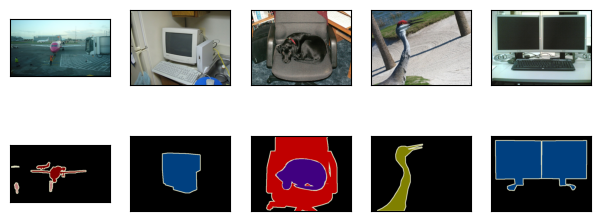

In [4]:
# Visual sanity check: top row = input images, bottom row = their color masks.
n = 5

# imges : List: [train_image1, train_image2, ..., train_image5, train_label1, train_label2, ..., train_label5]
imgs = train_features[:n] + train_labels[:n]
imgs = [img.permute(1, 2, 0) for img in imgs]
d2l.show_images(imgs, 2, n);

In [5]:
#@save
# Pascal VOC 21 classes (background + 20 foreground classes) encoded by fixed RGB colors.
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

#@save
# Class names aligned with VOC_COLORMAP indices.
VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

In [6]:
#@save
def voc_colormap2label():
    """Build a lookup table that maps RGB colors to VOC class indices."""
    # 24-bit RGB gives 256^3 possible colors; we preallocate a direct-index table.
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        # Pack (R, G, B) into a unique integer key: (R*256 + G)*256 + B.
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

#@save
def voc_label_indices(colormap, colormap2label):
    """Convert an RGB segmentation mask to per-pixel class IDs."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    # Output shape: (H, W), each value in [0, 20].
    return colormap2label[idx]

In [7]:
# Demonstrate color-mask -> class-index conversion on one image(train_labels[0]).
y = voc_label_indices(train_labels[0], voc_colormap2label())
# Inspect a small patch of the image; compare value meanings with VOC_CLASSES.
y[105:115, 130:140], VOC_CLASSES[1]

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]),
 'aeroplane')

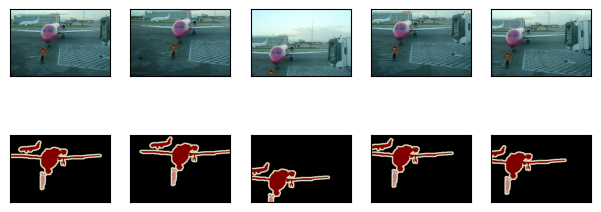

In [ ]:
# Data preprocessing for segmentation must keep exact pixel alignment between
# image and label mask.
#
## Why we do NOT reuse "rescale/resize" style preprocessing from classification:
# 1) Classification has one label per image, so geometric distortion is usually
#    acceptable as long as object identity is preserved.
# 2) Segmentation has one label per pixel, so every pixel location matters.
# 3) If image and mask are resized independently, tiny interpolation or rounding
#    differences can shift boundaries and create wrong supervision.
# 4) If bilinear/bicubic interpolation is applied to label masks, class IDs get
#    mixed into invalid values (because labels are categorical, not continuous).
# 5) Even nearest-neighbor resize on masks can still change boundary geometry and
#    small-object shapes; this is often unavoidable when enforcing a fixed size,
#    so we prefer a safer augmentation here.
#
## Why random crop is used instead:
# - We sample one rectangle and apply it to BOTH image and mask.
# - This preserves one-to-one pixel correspondence after augmentation.
# - Labels remain valid class IDs (no interpolation mixing).
# - It also controls memory/compute while adding spatial variation.

def voc_rand_crop(feature, label, height, width):
    # Use one random rectangle and apply it to both tensors.
    # This preserves the exact pixel-to-label correspondence required by segmentation.
    rect = torchvision.transforms.RandomCrop.get_params(feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

imgs = []
for _ in range(n):
    # Show multiple random crops to visualize paired augmentation behavior.
    imgs += voc_rand_crop(train_features[0], train_labels[0], 200, 300)

imgs = [img.permute(1, 2, 0) for img in imgs]
d2l.show_images(imgs[::2] + imgs[1::2], 2, n);

In [ ]:
# Define a custom semantic segmentation dataset class VOCSegDataset by inheriting the 
# Dataset class provided by high-level APIs. By implementing the __getitem__ function, 
# we can arbitrarily access the input image indexed as idx in the dataset and the class 
# index of each pixel in this image. Since some images in the dataset have a smaller size
# than the output size of random cropping, these examples are filtered out by a custom 
# filter function. In addition, we also define the normalize_image function to standardize 
# the values of the three RGB channels of input images.

#@save
class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC segmentation dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        # ImageNet normalization is applied to feature images only (not label masks).
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)

        # Keep only images large enough for the requested random crop size.
        # This avoids invalid crop coordinates during training.
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)

        # Precompute color->class lookup for fast per-pixel label conversion.
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        # Apply identical random crop to image and mask, then map mask RGB->class IDs.
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

In [ ]:
# Build train/validation datasets with fixed crop size used by FCN training.
crop_size = (320, 480)
voc_train = VOCSegDataset(True, crop_size, voc_dir)
voc_test = VOCSegDataset(False, crop_size, voc_dir)

In [ ]:
batch_size = 64
train_iter = torch.utils.data.DataLoader(voc_train, batch_size, shuffle=True,
                                    drop_last=True,
                                    num_workers=0)

# num_workers=0 is slower but more stable in notebook/devcontainer environments.
# drop_last=True keeps batch shapes consistent for training loops and plotting.
for X, Y in train_iter:
    # X: (B, 3, H, W), normalized images; Y: (B, H, W), integer class indices.
    print(X.shape)
    print(Y.shape)
    break

In [ ]:
#@save
def load_data_voc(batch_size, crop_size, num_workers=0):
    """Load the VOC semantic segmentation dataset."""
    # Reuse local extracted data to avoid heavy in-kernel extraction.
    voc_dir = os.path.join('..', 'data', 'VOCdevkit', 'VOC2012')
    if not os.path.isdir(voc_dir):
        raise RuntimeError(
            'VOC dataset not found at ../data/VOCdevkit/VOC2012. '
            'Extract it first in terminal.'
        )

    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

================================ Transposed Convolution ================================

### The Problem: Upsampling

CNNs progressively **downsample** spatial resolution (via convolution strides and pooling). For dense prediction tasks like semantic segmentation, we need to **upsample** back to the original resolution.

**Transposed convolution** (sometimes called "deconvolution") is a learnable upsampling operation.

### How Transposed Convolution Works

A standard convolution maps a larger input to a smaller output. A transposed convolution does the **reverse**: it maps a smaller input to a larger output.

#### Basic Operation (no padding, no stride)

For input size $n$, kernel size $k$:
- **Standard conv**: output size = $n - k + 1$ (shrinks)
- **Transposed conv**: output size = $n + k - 1$ (grows)

The transposed convolution:
1. Places each input element as the **center** of a scaled copy of the kernel.
2. **Sums** overlapping contributions.

$$\text{Output}[i+a, j+b] \mathrel{+}= \text{Input}[i, j] \times \text{Kernel}[a, b]$$

### With Padding and Stride

| Parameter | Effect on Transposed Conv |
|---|---|
| **Padding** $p$ | Removes $p$ rows/cols from output border → output size **decreases** |
| **Stride** $s$ | Inserts $s-1$ zeros between input elements → output size **increases** |

Output size formula:

$$o = s \cdot (n - 1) + k - 2p$$

Common configuration to **exactly double** resolution: $k=4, s=2, p=1$ → $o = 2n$.

### Implementation

```python
# Transposed conv that doubles spatial resolution
tconv = nn.ConvTranspose2d(in_channels, out_channels,
                           kernel_size=4, stride=2, padding=1)
# Input: (batch, C, H, W) → Output: (batch, C', 2H, 2W)
```

### Connection to Standard Convolution

The transposed convolution is the **transpose** of the matrix form of standard convolution. If standard conv is represented as matrix $\mathbf{W}$:
- Forward (conv): $\mathbf{y} = \mathbf{W} \mathbf{x}$
- Transposed conv: $\mathbf{x}' = \mathbf{W}^\top \mathbf{y}$

**Note**: Transposed convolution is NOT the inverse of convolution — it does not recover the original input.

### Key Takeaways

- Transposed convolution is a **learnable upsampling** operation essential for dense prediction.
- It increases spatial resolution by the stride factor.
- Kernel weights are **learned**, unlike bilinear/nearest-neighbor upsampling.
- The $k=4, s=2, p=1$ configuration is standard for $2\times$ upsampling.
- It's the building block for decoder networks in U-Net, FCN, and generative models (GANs).

============================= Fully Convolutional Networks (FCN) =============================

### Overview

**Fully Convolutional Networks (FCN)** (Long et al., 2015) pioneered using CNNs for **pixel-level** semantic segmentation by replacing fully connected layers with convolutional layers and adding transposed convolutions for upsampling.

### Architecture

```
Input Image (H × W × 3)
    ↓
Pretrained CNN Backbone (e.g., ResNet-18)
    → Feature Map (H/32 × W/32 × 512)   [encoder/downsampling path]
    ↓
1×1 Convolution (512 → num_classes)
    → Score Map (H/32 × W/32 × num_classes)
    ↓
Transposed Convolution (×32 upsampling)
    → Dense Prediction (H × W × num_classes)
    ↓
argmax per pixel → Segmentation Map
```

### Key Ideas

#### 1. Replace FC Layers with Convolutions
- Standard classification CNNs end with FC layers (fixed input size).
- FCN replaces them with $1 \times 1$ convolutions → can handle **any input size**.
- The $1 \times 1$ conv projects channel features to `num_classes` at each spatial position.

#### 2. Transposed Convolution for Upsampling
- The backbone reduces resolution by $32\times$ (5 pooling layers with stride 2).
- A transposed convolution **upsamples** back to original resolution.
- Initialized with **bilinear interpolation** weights for stable training.

```python
def bilinear_kernel(in_channels, out_channels, kernel_size):
    """Initialize transposed conv weights for bilinear upsampling."""
    factor = (kernel_size + 1) // 2
    center = (kernel_size - 1) / 2
    og = torch.arange(kernel_size).reshape(-1, 1).float()
    filt = (1 - torch.abs(og - center) / factor) * \
           (1 - torch.abs(og.T - center) / factor)
    weight = torch.zeros(in_channels, out_channels, kernel_size, kernel_size)
    for i in range(in_channels):
        weight[i, i % out_channels] = filt
    return weight
```

#### 3. Transfer Learning
- Use a pretrained backbone (ResNet) as the encoder — features are already good.
- Only the $1 \times 1$ conv and transposed conv layers need training from scratch.

### Training

- **Loss**: Cross-entropy loss per pixel.
- **Input**: Random crops of images + label maps (same crop for both).
- **Output**: Per-pixel class predictions.

### Key Takeaways

- FCN was the **first** end-to-end trainable architecture for semantic segmentation.
- Key insight: replace FC layers with $1 \times 1$ conv → spatial output instead of vector output.
- **Bilinear initialization** of transposed convolution weights stabilizes training.
- Modern successors: U-Net (skip connections), DeepLab (atrous/dilated convolutions), PSPNet (pyramid pooling).

=================================== Neural Style Transfer ===================================

### Overview

**Neural Style Transfer** (Gatys et al., 2016) combines the **content** of one image with the **style** of another to produce a new, stylized image. It leverages CNN feature representations extracted from a pretrained network (VGG-19).

### How It Works

```
Content Image (photograph)  +  Style Image (painting)
                    ↓
    Optimization: find a Synthesized Image that
    minimizes content loss + style loss + TV loss
                    ↓
    Stylized Output Image
```

The synthesized image is the **variable being optimized** (not the network weights).

### Loss Functions

#### 1. Content Loss

Measures how similar the synthesis is to the content image **in feature space**:

$$\mathcal{L}_{\text{content}} = \frac{1}{2} \| \mathbf{F}^{(l)}_{\text{synth}} - \mathbf{F}^{(l)}_{\text{content}} \|_F^2$$

- Extracted from a **single deep layer** (e.g., `conv4_2` of VGG-19).
- Deep features capture **high-level structure** (objects, layout) but not exact pixels.

#### 2. Style Loss

Measures how similar the **texture/style** is using **Gram matrices**:

$$\mathbf{G}^{(l)} = \mathbf{F}^{(l)} {\mathbf{F}^{(l)}}^\top$$

The Gram matrix captures **correlations between feature channels** — encoding texture, color patterns, and brushstroke-like information.

$$\mathcal{L}_{\text{style}} = \sum_l w_l \| \mathbf{G}^{(l)}_{\text{synth}} - \mathbf{G}^{(l)}_{\text{style}} \|_F^2$$

- Computed across **multiple layers** (e.g., `conv1_1` through `conv5_1`) to capture style at different scales.

#### 3. Total Variation (TV) Loss

Encourages spatial smoothness, reducing noise:

$$\mathcal{L}_{\text{TV}} = \sum_{i,j} \left| x_{i+1,j} - x_{i,j} \right| + \left| x_{i,j+1} - x_{i,j} \right|$$

#### Combined Loss

$$\mathcal{L} = \alpha \cdot \mathcal{L}_{\text{content}} + \beta \cdot \mathcal{L}_{\text{style}} + \gamma \cdot \mathcal{L}_{\text{TV}}$$

- $\alpha, \beta, \gamma$ control the balance between content fidelity, style strength, and smoothness.

### Optimization

- Initialize synthesized image as the content image (or random noise).
- **Freeze** the VGG-19 network (pretrained, not training it).
- Use gradient descent (L-BFGS or Adam) to update **pixel values** of the synthesized image.

### Key Takeaways

- Neural style transfer is an **optimization over pixels**, not over network weights.
- **Content loss** (deep features) preserves structure; **style loss** (Gram matrices) transfers texture/patterns.
- VGG-19 features at different depths capture different abstraction levels of content and style.
- The Gram matrix is a powerful representation of **texture** independent of spatial arrangement.
- $\alpha/\beta$ ratio controls the content–style tradeoff.

============================= Image Classification (CIFAR-10) on Kaggle =============================

### Overview

This section walks through a complete Kaggle competition pipeline for **CIFAR-10 image classification** (10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). It covers data organization, augmentation, model selection, and submission.

### Dataset Details

| Property | Value |
|---|---|
| **Training images** | 50,000 (5,000 per class) |
| **Test images** | 300,000 (Kaggle test set) |
| **Image size** | $32 \times 32 \times 3$ |
| **Classes** | 10 |

### Pipeline

#### 1. Data Organization

```
data/cifar-10/
├── train/           # 50,000 images: id.png
├── test/            # 300,000 images: id.png
├── trainLabels.csv  # id → label mapping
└── sampleSubmission.csv
    ↓ reorganize into:
train_valid_test/
├── train/          # Per-class folders (for DataLoader)
│   ├── airplane/
│   ├── automobile/
│   └── ...
├── valid/          # Hold-out validation set
├── train_valid/    # Full training set (for final submission)
└── test/
```

#### 2. Image Augmentation

```python
transform_train = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(32, scale=(0.64, 1.0), ratio=(1.0, 1.0)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],
                                     [0.2023, 0.1994, 0.2010])])
```

- Training: random crop + horizontal flip + normalization.
- Test: only normalization (no augmentation).

#### 3. Model

- Use **ResNet-18** (or deeper) — modify first conv for $32 \times 32$ input (smaller kernel, no stride).
- Can fine-tune from pretrained ImageNet weights or train from scratch.

#### 4. Training Strategy

- **K-fold cross-validation** to tune hyperparameters.
- After finding best hyperparameters, retrain on **full training set** (train + validation).
- Generate predictions on test set → submit to Kaggle.

#### 5. Submission

```python
# Predict on test set, write CSV
# Columns: id, predicted_label
```

### Key Takeaways

- A complete competition pipeline: data preprocessing → augmentation → model → training → submission.
- **Data augmentation** is critical for small-image datasets like CIFAR-10.
- **K-fold cross-validation** helps select robust hyperparameters.
- Retrain on the **full dataset** for the final submission to maximize performance.
- CIFAR-10 is a stepping stone to harder benchmarks (CIFAR-100, ImageNet).

=================== Dog Breed Identification (ImageNet Dogs) on Kaggle ===================

### Overview

This Kaggle competition requires classifying images into **120 dog breeds** — a fine-grained classification task where differences between classes are subtle (e.g., distinguishing a Siberian Husky from an Alaskan Malamute).

### Why This Is Harder Than CIFAR-10

| Challenge | CIFAR-10 | Dog Breeds |
|---|---|---|
| **Classes** | 10 (very different) | 120 (very similar) |
| **Image size** | $32 \times 32$ | Variable (high-res) |
| **Difficulty** | Low | High (fine-grained) |
| **Data per class** | 5,000 | ~100 |

### Pipeline

#### 1. Data Preprocessing

- Images are **variable size** → resize to $224 \times 224$ (standard ImageNet input).
- Use **ImageNet normalization** (mean and std of ImageNet dataset).

#### 2. Heavy Data Augmentation

Fine-grained classification with limited data demands aggressive augmentation:

```python
transform_train = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224, scale=(0.08, 1.0), ratio=(3/4, 4/3)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])])
```

#### 3. Transfer Learning (Essential!)

- Use a **pretrained ResNet** (or other ImageNet model) — these models have already seen dogs.
- Replace the final FC layer: 1000 classes → 120 dog breeds.
- Fine-tune with a **small learning rate** on pretrained layers, larger on the new head.

```python
pretrained_net = torchvision.models.resnet34(pretrained=True)
# Freeze most layers, replace output
pretrained_net.fc = nn.Linear(pretrained_net.fc.in_features, 120)
```

#### 4. Training

- Use **cross-entropy loss**.
- Fine-tune for ~20–80 epochs with cosine/step learning rate schedule.
- Monitor validation accuracy to avoid overfitting.

#### 5. Submission

- Predict **probabilities** for all 120 classes (not just top-1).
- Kaggle evaluates with **log-loss** (cross-entropy), so calibrated probabilities matter.

### Key Takeaways

- **Fine-grained classification** is much harder than coarse classification — classes are visually similar.
- **Transfer learning** is essential when per-class data is scarce (~100 images per breed).
- **Aggressive augmentation** (random crop, color jitter, flips) helps prevent overfitting on small data.
- Pretrained ImageNet features are highly relevant since the source dataset already contains dog images.
- **Log-loss** evaluation means the model must output well-calibrated probabilities, not just correct labels.